# Kernel SVM

La différence avec Linear SVM c'est qu'on va pouvoir séparer les données sans forcément tracer une droite mais une courbe. Le truc magique du Kernel SVM c'est de projet les données dans un esapce de dimension supérieur où elles deviennet linéairement séparables. 

Un **kernel** est une fonction qui permet à SVM de séparer des données non-linéaires, sans avoir besoin de connaître explictement les coordonnées dans un espace de dimension plus élevée. Le kernel permet de calculer la distance ou la similarité des points comme si ils étaient projetés dans un espace plus complexe: Kernel Trick.  
Différents noyaux:
| Type | Nom | Formule Mathématique | Description |
| :--- | :--- | :--- | :--- |
| **Linéaire** | Linear | $k(\mathbf{x}, \mathbf{z}) = \mathbf{x}^\top \mathbf{z}$ |Pas de transformation. |
| **Polynomial** | Polynomial | $k(\mathbf{x}, \mathbf{z}) = (\mathbf{x}^\top \mathbf{z} + \sigma)^p$ | Séparation par courbes. |
| **Radial** | Gaussian (RBF) | $k(\mathbf{x}, \mathbf{z}) = \exp\left(-\frac{\|\mathbf{x}-\mathbf{z}\|^2}{2\sigma^2}\right)$ | Dimension infinie. |
| **Radial** | Laplacian | $k(\mathbf{x}, \mathbf{z}) = \exp\left(-\frac{\|\mathbf{x}-\mathbf{z}\|}{\sigma}\right)$ | Basé sur la distance $L_1$. |

Pour être utilisé avec un SVM, un noyau $k$ doit être défini positif afin de garantir que le problème d'optimisation (le problème dual) est bien posé.
- Symétrie: $k(\mathbf{x}, \mathbf{z}) = k(\mathbf{z}, \mathbf{x})$.
- Condition de positivité: $\sum \sum \alpha_i \alpha_j k(\mathbf{x}_i, \mathbf{x}_j) >= 0$ 

## Synthetic data

In [33]:
from sklearn.datasets import make_moons
import numpy as np
from sklearn.model_selection import train_test_split
n = 900

# fonction qui génère des données en forme de deux lunes entrelacées
# noise=0.25: rend les lunes un peu imparfaite
# random_state fixe la graine du générateur pour obtenir les mêmes points à chaque exécution
X,Y = make_moons(n_samples=n, noise=0.25, random_state=42)

In [34]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, shuffle=True, test_size=1/3)
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, shuffle=True, 
                                                  test_size=1/2)

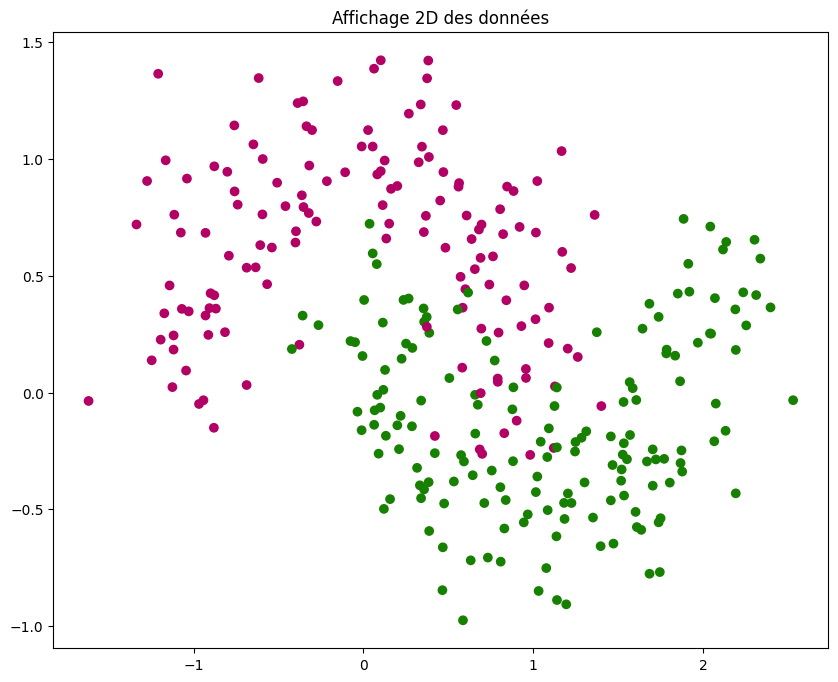

In [35]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
cm = plt.cm.PiYG
cm_bright = ListedColormap(["#b30065", "#178000"])
plt.figure(figsize=(10,8))
plt.scatter(X_train[:, 0], X_train[:, 1], c=Y_train, cmap=cm_bright)
plt.title("Affichage 2D des données");

Les deux classes ne sont clairement pas séparables via une droite.

In [36]:
from sklearn.svm import SVC

# kernel{‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘precomputed’} or callable, default=’rbf’
clfker = SVC(kernel="rbf")
clfker.gamma = 0.1
clfker.C = 10
# gamma et C sont pris en compte au moment du clfker.fit, mais la doc recommande d'écrire:
# clfkfer = SVC(kernel="rbf", gamma=0.1, C=10)

Gamma (γ): contrôle jusqu'à quelle distance un point influence la frontière de décision.
- γ petit: Influence large, frontière lisse. Risque de sous-apprentissage si trop petit.
- γ grand: Influence faible (locale), frontière sinueuse. Risque de surapprentissage (overfitting).

C: représente la tolérance aux erreurs de classification
- C petit: Marge large, accepte des erreurs. Risque de sous-apprentissage si trop petit.
- C grand: Marge étroite, peu d'erreurs permises. Risque de surapprentissage.

In [37]:
clfker.fit(X_train, Y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


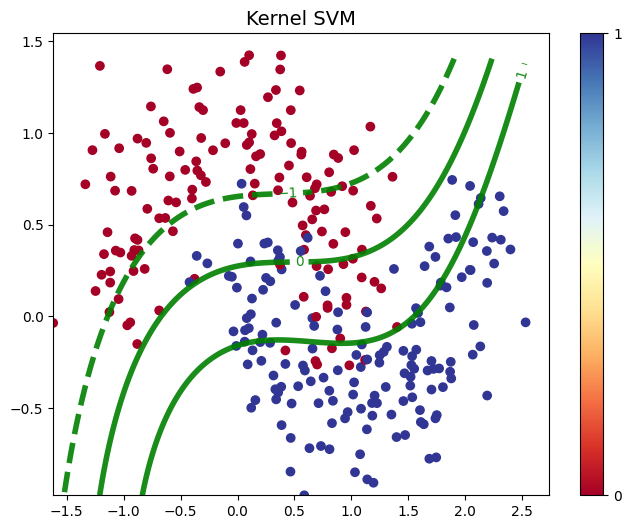

In [38]:
from utility_svm import plot_decision_regions_2d
plot_decision_regions_2d(X_train, Y_train, clfker, 0.02, title="Kernel SVM")

Ce n'est pas une très bonne séparation, les marges sont trop grosses, les courbes trop lissées, il faut trouver les meilleurs hyperparamètres.

Etudions l'influence du paramètre γ:

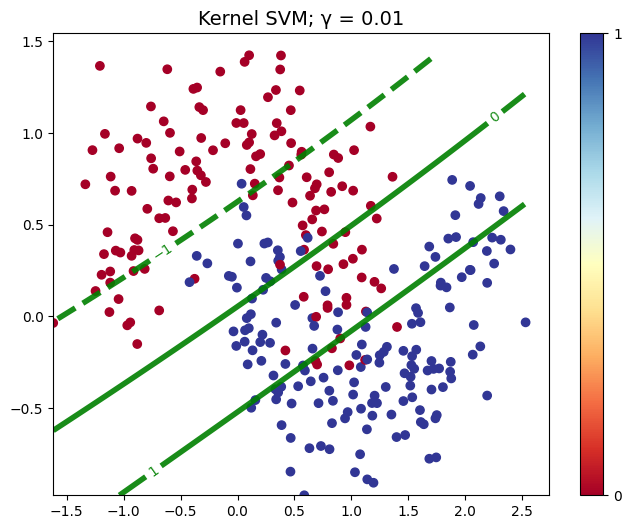

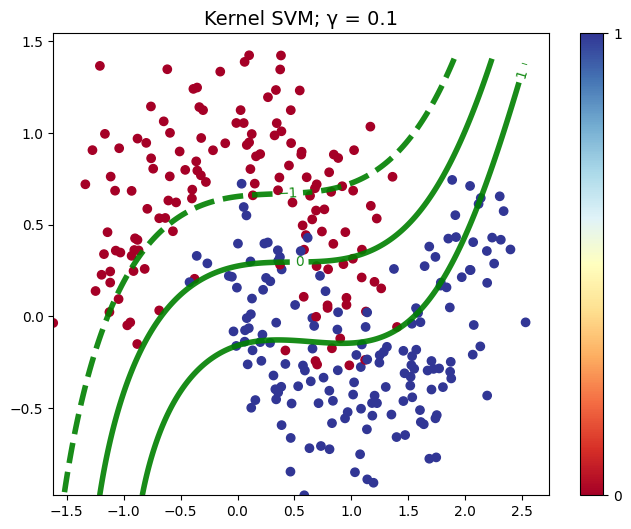

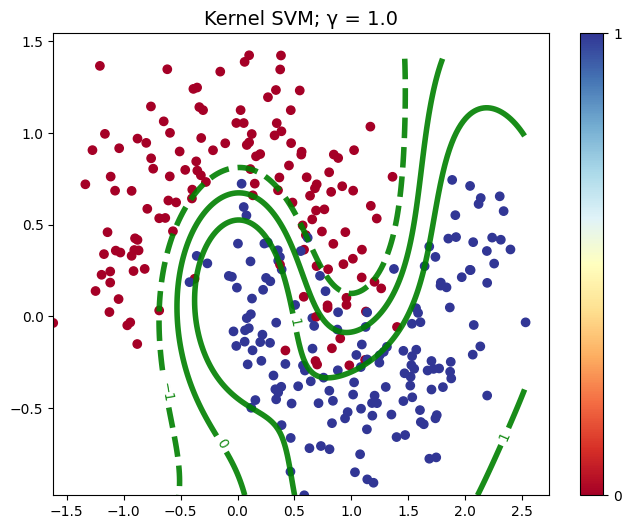

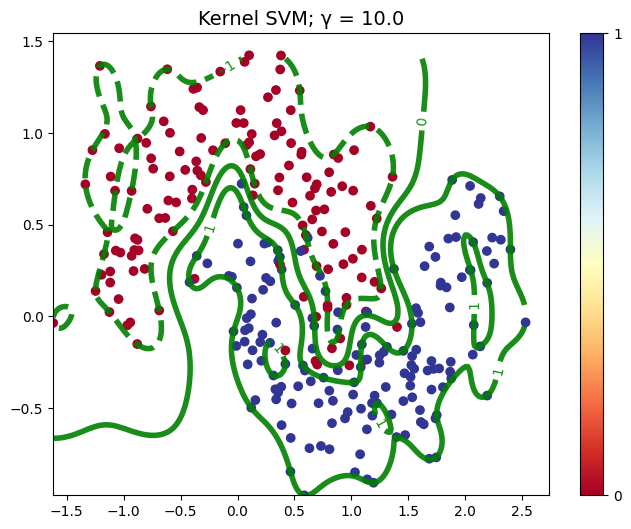

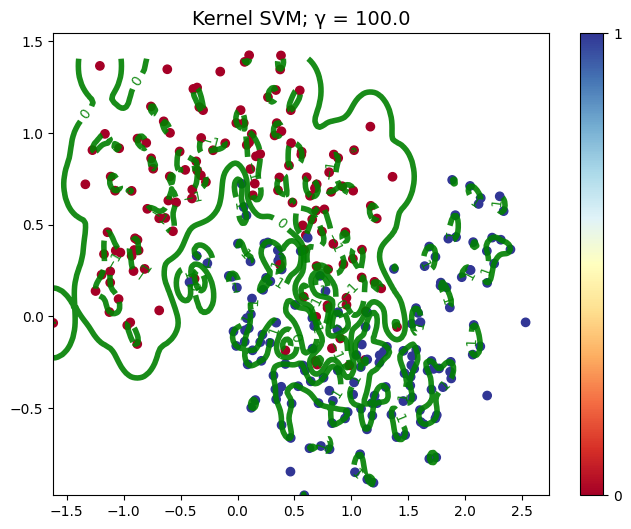

In [39]:
for gamma in np.logspace(-2, 2, 5):
    clfker = SVC(kernel="rbf", gamma = gamma, C = 10)
    clfker.fit(X_train, Y_train)
    plot_decision_regions_2d(X_train, Y_train, clfker, 0.02, title=f"Kernel SVM; γ = {gamma}")

- Pour les petites valeurs de gamma: La frontière de décision est très droite ou très lisse (influence large des points).
- Pour les grandes valeurs de gamma: La frontière créé des "bulles" autour de chaque point, ce qui correspond au surapprentissage

Ici, on veut une valeur de gamme positive mais inférieure à 10 au moins.

Cherchons le meilleur couple (γ,C):

In [40]:
from sklearn.metrics import accuracy_score

vectC = np.logspace(-3, 2, 6)
vectGamma = np.logspace(-2, 2, 6)

err_val = np.empty((vectC.shape[0], vectGamma.shape[0]))

for ind_C, C in enumerate(vectC):
    clfker.C = C
    for ind_gam, paramKer in enumerate(vectGamma):
        clfker.gamma = paramKer
        clfker.fit(X_train, Y_train)
        err_val[ind_C, ind_gam]= 1 - accuracy_score(Y_val, clfker.predict(
        X_val))

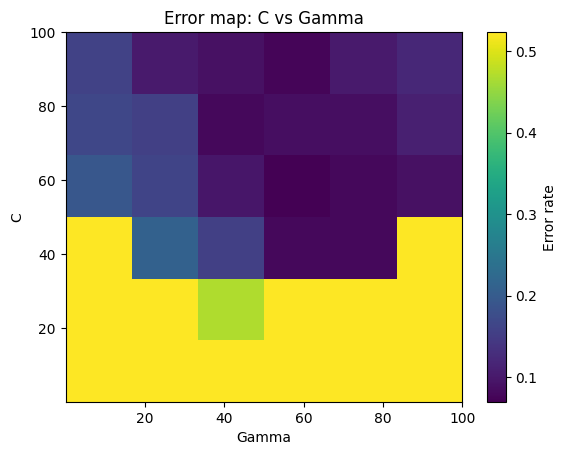

In [41]:
fig, ax = plt.subplots()

ax.imshow(
    err_val,
    extent=[vectGamma.min(), vectGamma.max(), vectC.min(), vectC.max()],
    origin='lower',
    aspect='auto'
)

# ax.set_xticks([])  # enlève les ticks sur X
# ax.set_yticks([])  # enlève les ticks sur Y

ax.set_xlabel("Gamma")
ax.set_ylabel("C")
ax.set_title("Error map: C vs Gamma")

plt.colorbar(ax.images[0], label="Error rate")
plt.show()

- Influence de Gamma ($\gamma$) : Avec un $\gamma$ très grand, l'influence devient trop locale, créant une frontière sinueuse et augmentant l'erreur de généralisation (surapprentissage).
- Influence de C: Sur l'axe vertical, une valeur de $C$ trop petite (bas du graphique) accepte trop d'erreurs, ce qui mène au sous-apprentissage et fait grimper le taux d'erreur vers les couleurs claires.

In [42]:
ind_C, ind_gamma = np.unravel_index(np.argmin(err_val), err_val.shape)
Copt = vectC[ind_C]
GammaOpt = vectGamma[ind_gamma]
print(f"C optimal: {Copt}\nGamma optimal: {GammaOpt}")

C optimal: 1.0
Gamma optimal: 2.5118864315095824


Erreur de validation : 7.00%


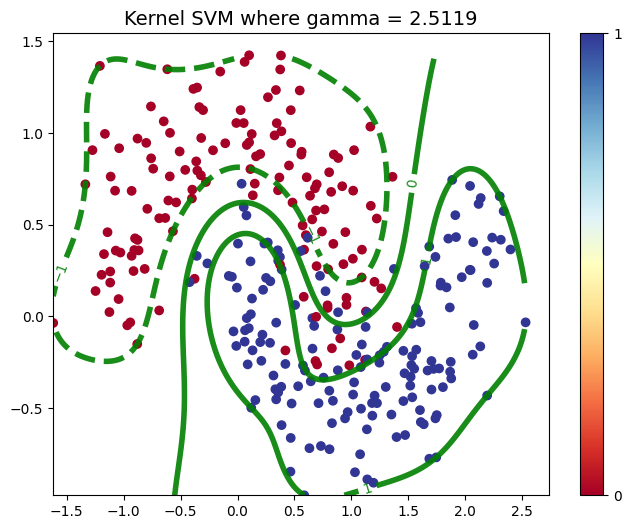

In [47]:
clfker = SVC(kernel="rbf")
clfker.gamma = GammaOpt
clfker.C = Copt
clfker.fit(X_train, Y_train)

plot_decision_regions_2d(X_train, Y_train, clfker, 0.02, title=f"Kernel SVM where gamma = {GammaOpt:.4f}")
err_val= 1 - accuracy_score(Y_val, clfker.predict(X_val))
print(f"Erreur de validation : {100*err_val:.2f}%")

Erreur de test : 5.00%


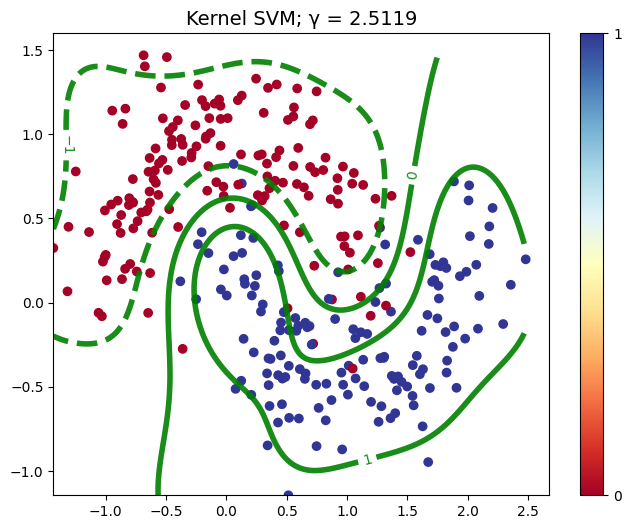

In [52]:
clfker = SVC(kernel="rbf", gamma = GammaOpt, C = Copt)
clfker.fit(X_train, Y_train)
plot_decision_regions_2d(X_test, Y_test, clfker, 0.02, title=f"Kernel SVM; γ = {GammaOpt:.4f}")
err_test= 1 - accuracy_score(Y_test, clfker.predict(X_test))
print(f"Erreur de test : {100*err_test:.2f}%")

**Utilisaition du kernel polynomial**:

In [68]:
clfker = SVC(kernel="poly", gamma="scale", coef0=1, C=Copt)
# paramètre p: degree: définit la complexité de la courbe (ex: 1 pour une droite, 2 pour une parabole, etc.)
# paramètre coef0: aide à contrôler l'influence des termes de haut degré par rapport aux termes de bas degré
# paramètre C: reste présent pour gérer la tolérance aux erreurs, comme pour le RBF

In [69]:
# np.linspace: séquence de 1 à 7 qui génère 7 éléments
vectDegree = np.linspace(1, 7, 7)
err_val = np.empty(vectDegree.shape[0])
err_train = np.empty(vectDegree.shape[0])
err_test = np.empty(vectDegree.shape[0])

for i, deg in enumerate(vectDegree):
    clfker.degree = int(deg)
    clfker.fit(X_train, Y_train)
    err_train[i]= 1 - accuracy_score(Y_train, clfker.predict(X_train))
    err_test[i]= 1 - accuracy_score(Y_test, clfker.predict(X_test))
    err_val[i]= 1 - accuracy_score(Y_val, clfker.predict(X_val))

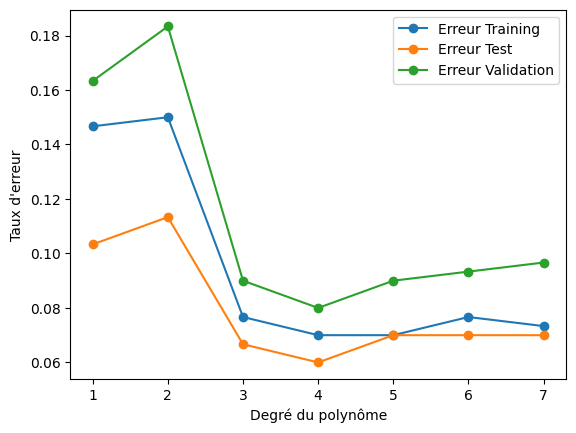

In [70]:
plt.plot(vectDegree, err_train, 'o-', label='Erreur Training')
plt.plot(vectDegree, err_test, 'o-', label='Erreur Test')
plt.plot(vectDegree, err_val, 'o-', label='Erreur Validation')
plt.xlabel('Degré du polynôme')
plt.ylabel('Taux d\'erreur')
plt.legend()
plt.show()

In [71]:
ind_deg = np.argmin(err_val)
degOpt = vectDegree[ind_deg]
print(f"Degré optimal : {degOpt}\nErreur au degré optimal : {err_val[ind_deg]}")

Degré optimal : 4.0
Erreur au degré optimal : 0.07999999999999996


Erreur de validation : 0.07999999999999996


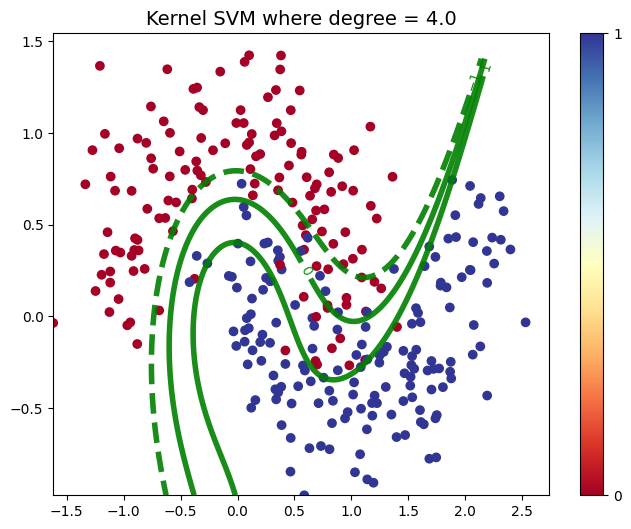

In [72]:
clfker = SVC(kernel="poly", gamma="scale" , coef0=1)
clfker.degree = int(degOpt)
clfker.fit(X_train, Y_train)

plot_decision_regions_2d(X_train, Y_train, clfker, 0.02, title=f"Kernel SVM where degree = {degOpt}")
err_val= 1 - accuracy_score(Y_val, clfker.predict(X_val))
print(f"Erreur de validation : {err_val}")

L'erreur de validaiton a augmenté d'un point, c'est donc un peu moins bien pour les données actuelles mais peut être qu'une autre graine aurait donné plutôt un meilleur score pour le kernel polynomial. Aussi, je n'ai pas réaliser de GriSearch ici.

## Spam classification

In [95]:
dataspam = np.loadtxt("spambase/spambase.data", delimiter=",")
features_name = np.genfromtxt("spambase/spambase_variables.csv", delimiter=",", dtype="str")
features_name = features_name[:,0]
X = dataspam[:,0:57]
Y = dataspam[:,-1]

In [103]:
# entraînement sur Train set
# Optimisation des paramètres via Validation Set
# Prédiction sur Test set

In [96]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= 1/3, train_size = 2/3)
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.5)

In [97]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler(with_mean=True, with_std=True)

sc = sc.fit(X_train)
X_train = sc.transform(X_train)
X_val = sc.transform(X_val)
X_test = sc.transform(X_test)

In [98]:
clfspam = SVC(kernel="rbf")

In [99]:
vectC = np.logspace(-5, 2, 8)
vectGamma = np.logspace(-3, 3, 8)
err_val = np.empty((vectC.shape[0], vectGamma.shape[0]))
for ind_C, C in enumerate(vectC):
    clfspam.C = C
    for ind_gam, paramKer in enumerate(vectGamma):
        clfspam.gamma = paramKer
        clfspam.fit(X_train, Y_train)
        err_val[ind_C, ind_gam]= 1 - accuracy_score(Y_val, clfspam.predict(X_val))

In [100]:
ind_C, ind_gamma = np.unravel_index(np.argmin(err_val), err_val.shape)
Copt = vectC[ind_C]
GammaOpt = vectGamma[ind_gamma]

In [101]:
print(f"C optimal : {Copt}\nGamma optimal : {GammaOpt}")

C optimal : 100.0
Gamma optimal : 0.001


In [102]:
clfspam = SVC(kernel="rbf")
clfspam.gamma = GammaOpt
clfspam.C = Copt
clfspam.fit(X_train, Y_train)

err_test= 1 - accuracy_score(Y_test, clfspam.predict(X_test))
print(f"Erreur de test : {err_test}")

Erreur de test : 0.06584093872229468


En ce qui concerne spam classification, on a testé différents modèles:
- Logistic Regression: taux d'erreur de test de 8%.
- Linear SVM: taux d'erreur de test de 7%.
- Kernel SVM: taux d'erreur de test de 6%.

Donc le modèle le plus approprié pour ces données semble être le kernel SVM rbf.